# STAPLE by hand
In this hands-on session we will merge segmentation masks with STAPLE, first with a synthetic example and then with real-life annotations.

The idea behind STAPLE is: if raters are unequal, we can estimate a hidden true mask **and** how good each rater is, all at the same time.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import SimpleITK as sitk
from PIL import Image

In [2]:
def dice(a, b):
    a, b = a.astype(bool), b.astype(bool)
    s = a.sum() + b.sum()
    return 2 * (a & b).sum() / s if s else 1.0

### A set of synthetic annotations
We have five raters annotating a lesion (a circle). A and B are careful annotators. C and D include the lesions plus an extra region. E is not even trying, it could even be modeled as label noise, but for the sake of illustration let us accept it is not noise but an unskilled annotator.

In [3]:
n = 96
yy, xx = np.ogrid[:n, :n]
cy, cx = n / 2, n / 2

def ellipse(ry, rx):
    return ((yy - cy) / ry) ** 2 + ((xx - cx) / rx) ** 2 <= 1

tight = ellipse(28, 32)
extra_C = (yy - 30) ** 2 + (xx - 75) ** 2 <= 12 ** 2
extra_D = (yy - 75) ** 2 + (xx - 30) ** 2 <= 10 ** 2

In [4]:
rng = np.random.RandomState(0)
junk = rng.rand(n, n) > 0.75
junk[:18] = 0
junk[-18:] = 0  # keep the noise in the middle so it is impossible to miss

In [5]:
names = ['A careful', 'B careful', 'C extra', 'D extra', 'E junk']
masks = [tight, tight.copy(), tight | extra_C, tight | extra_D, junk]

Let us have a look at the data.

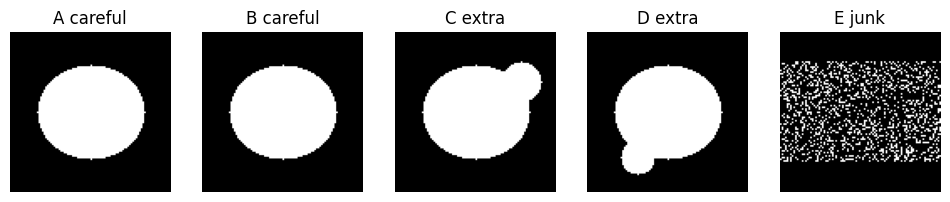

In [6]:
fig, axs = plt.subplots(1, 5, figsize=(12, 2.6))
for ax, m, name in zip(axs, masks, names):
    ax.imshow(m, cmap='gray', vmin=0, vmax=1)
    ax.set_title(name); ax.axis('off')
plt.show()

If we treat raters as **exchangeable**, fusion is just a histogram of votes, i.e. the pixel-wise mean. Then threshold at 0.5 and we have **majority vote.**

In [7]:
D = np.stack([m.astype(float) for m in masks], axis=0)
T0 = D.mean(axis=0)
majority = T0 >= 0.5

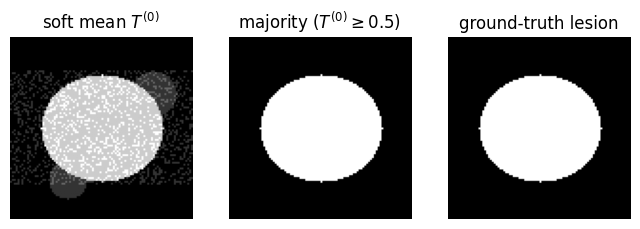

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(8, 2.8))
axs[0].imshow(T0, cmap='gray', vmin=0, vmax=1)
axs[0].set_title('soft mean $T^{(0)}$')
axs[1].imshow(majority, cmap='gray', vmin=0, vmax=1)
axs[1].set_title('majority ($T^{(0)} \geq 0.5$)')
axs[2].imshow(tight, cmap='gray', vmin=0, vmax=1)
axs[2].set_title('ground-truth lesion')
for ax in axs:
    ax.axis('off')
plt.show()

Majority already removes the wrong E annotator, plus the extra regions of C and D only had one vote so, they died as well. Democracy worked, so why STAPLE?

Look at the **soft** $T^{(0)}$: those regions still show there as gray 0.2 pixels. STAPLE reweights raters and will take them out, while also scoring how much it trusts each annotation.

### STAPLE: two equations

STAPLE assumes there is a hidden true mask $T$, and rater $j$ has two scores:

* sensitivity $p_j$:  $P(D_j=1 \mid T=1)$  (do they see the lesion?)
* specificity $q_j$:  $P(D_j=0 \mid T=0)$  (do they avoid false positives?)

If we know $(p,q)$, we can rebuild $T$ using Bayes. If we know $T$, we can score $(p,q)$. Therefore we can implement an EM algorithm, alternating until it converges.

First, rebuild $T$ (E-step): for every pixel, $T$ is the posterior that the pixel is lesion given the votes and the current skills:

In [9]:
def staple_estep(D, p, q, prior):
    # D has shape (raters, H, W), values in {0, 1}
    prior = np.clip(prior, 1e-6, 1 - 1e-6)
    p = np.clip(p, 1e-6, 1 - 1e-6)
    q = np.clip(q, 1e-6, 1 - 1e-6)

    log_t1 = np.full(D.shape[1:], np.log(prior))
    log_t0 = np.full(D.shape[1:], np.log(1 - prior))
    for j in range(D.shape[0]):
        d = D[j]
        log_t1 = log_t1 + np.where(d, np.log(p[j]), np.log(1 - p[j]))
        log_t0 = log_t0 + np.where(d, np.log(1 - q[j]), np.log(q[j]))

    m = np.maximum(log_t1, log_t0)
    return np.exp(log_t1 - m) / (np.exp(log_t1 - m) + np.exp(log_t0 - m))

Then, given the obtained soft $T$, score the raters (M-step):

In [10]:
def staple_mstep(D, T, eps=1e-6):
    p = np.zeros(D.shape[0])
    q = np.zeros(D.shape[0])
    t1, t0 = T.sum(), (1 - T).sum()
    for j in range(D.shape[0]):
        p[j] = (T * D[j]).sum() / (t1 + eps)          # P(D=1 | T=1)
        q[j] = ((1 - T) * (1 - D[j])).sum() / (t0 + eps)  # P(D=0 | T=0)
    return np.clip(p, eps, 1 - eps), np.clip(q, eps, 1 - eps)

We start from the equal-weight mean, score everyone against it, rebuild $T$, and repeat. One iteration would be:

In [11]:
T = T0.copy()
prior = T.mean()

p, q = staple_mstep(D, T)
T = staple_estep(D, p, q, prior)
prior = T.mean()

pd.DataFrame({'sensitivity p': p, 'specificity q': q}, index=names).round(3)

,sensitivity p,specificity q
A careful,0.904,0.935
B careful,0.904,0.935
C extra,0.931,0.903
D extra,0.925,0.908
E junk,0.314,0.913


After **one** iteration the mask is already almost binary. 

What happens is, the E-step multiplies one likelihood per rater. Those numbers are like 0.9 vs 0.1, not like 0.5. Three people saying "background" give $0.9^3$ against $0.1^3$ on that pixel, so $T$ suddenly becomes 0. Once $T$ is essentially 0/1, further E-steps have nothing left to modify, so convergence to truth is in one step.

What can still change is the skill table: the M-step is just "given this $T$, how often did each rater agree with it?". That ratio is well-defined even when $T$ has stopped, and it takes a couple of extra M-steps to converge because we first scored raters against the soft mean $T^{(0)}$, then against the converged $T$. Let us keep iterating only to watch $p,q$ for each annotator:

In [12]:
T_hist = [T0, T.copy()]
for it in range(4):
    p, q = staple_mstep(D, T)
    T = staple_estep(D, p, q, prior)
    prior = T.mean()
    T_hist.append(T.copy())
    print('iter', it + 2, '  p =', np.round(p, 3), '  q =', np.round(q, 3))

pd.DataFrame({'sensitivity p': p, 'specificity q': q}, index=names).round(3)

iter 2   p = [0.999 0.999 1.    0.999 0.234]   q = [1.    1.    0.956 0.964 0.885]
iter 3   p = [1.    1.    1.    1.    0.234]   q = [1.    1.    0.956 0.964 0.884]
iter 4   p = [1.    1.    1.    1.    0.234]   q = [1.    1.    0.956 0.964 0.884]
iter 5   p = [1.    1.    1.    1.    0.234]   q = [1.    1.    0.956 0.964 0.884]


,sensitivity p,specificity q
A careful,1.000,1.000
B careful,1.000,1.000
C extra,1.000,0.956
D extra,1.000,0.964
E junk,0.234,0.884


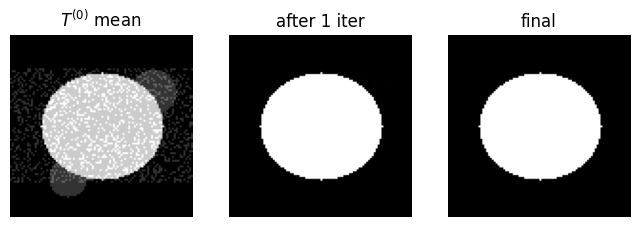

In [13]:
fig, axs = plt.subplots(1, 3, figsize=(8, 2.8))
for ax, imgT, title in zip(axs, [T_hist[0], T_hist[1], T_hist[-1]], ['$T^{(0)}$ mean', 'after 1 iter', 'final']):
    ax.imshow(imgT, cmap='gray', vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis('off')
plt.show()

$T$ is done after one step: the extra regions and E are gone, and the last masks are identical. The remaining iterations only refined the skills (E's sensitivity 0.31 → 0.23). A and B remain at $p=q=1$ because they are the consensus. STAPLE's extra bit, when majority had already recovered the lesion, is that we now have the skill table, revealing defective raters.

### SimpleITK's STAPLE
SimpleITK has `STAPLEImageFilter`, which returns a *probability* map, plus the final sensitivity / specificity. Let us compare it:

In [14]:
staple_filter = sitk.STAPLEImageFilter()
staple_filter.SetForegroundValue(1)

sitk_imgs = [sitk.GetImageFromArray(m.astype(np.uint8)) for m in masks]
prob_sitk = sitk.GetArrayFromImage(staple_filter.Execute(sitk_imgs))

In [15]:
print('iterations:', staple_filter.GetElapsedIterations())
pd.DataFrame({
    'sitk p': np.array(staple_filter.GetSensitivity()),
    'sitk q': np.array(staple_filter.GetSpecificity()),
    'ours p': p,
    'ours q': q,
}, index=names).round(3)

iterations: 3


,sitk p,sitk q,ours p,ours q
A careful,1.000,1.000,1.000,1.000
B careful,1.000,1.000,1.000,1.000
C extra,1.000,0.956,1.000,0.956
D extra,1.000,0.964,1.000,0.964
E junk,0.234,0.884,0.234,0.884


In [16]:
dice(prob_sitk >= 0.5, T >= 0.5)

np.float64(1.0)

Same solution is achieved.

## Real world data and caveats
STAPLE assumes there is a unique $T$, and that **agreement is skill**. That second assumption need not always hold.

A case from IMA++ is in `data/` (`ISIC_0000549`)

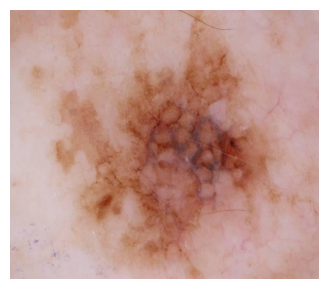

In [17]:
img = np.array(Image.open('data/ISIC_0000549.jpg'))
plt.figure(figsize=(4, 3.5))
plt.imshow(img)
plt.axis('off')
plt.show()

These are the available annotations:

* ISIC_0000549_A02_T1_S1.png - annotator A02, tool 1 (manual), drawn by expert
* ISIC_0000549_A03_T1_S1.png - annotator A03, tool 1 (manual), drawn by expert
* ISIC_0000549_A04_T3_S1.png - annotator A04, tool 3 (automated), reviewed by expert
* ISIC_0000549_A04_T3_S2.png - annotator A04, tool 3 (automated), reviewed by novice

In [18]:
rater_files = [
    ('A02  T1  S1', 'data/ISIC_0000549_A02_T1_S1.png'),
    ('A03  T1  S1', 'data/ISIC_0000549_A03_T1_S1.png'),
    ('A04  T3  S1', 'data/ISIC_0000549_A04_T3_S1.png'),
    ('A04  T3  S2', 'data/ISIC_0000549_A04_T3_S2.png'),
]
names = [n for n, _ in rater_files]
masks = [np.array(Image.open(p)) > 127 for _, p in rater_files]

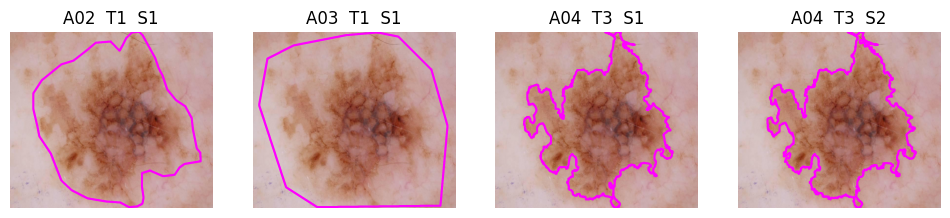

In [19]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
for ax, m, name in zip(axs, masks, names):
    ax.imshow(img)
    ax.contour(m, levels=[0.5], colors=['magenta'], linewidths=1.5)
    ax.set_title(name)
    ax.axis('off')
plt.show()

A03 (manual, labeled as expert in the dataset) includes more of the borders. The two A04 masks are almost identical: same annotator, same automated tool, two records in the archive (S1 vs S2 is who reviewed that record, not two people). A02 lays in between. Let us run STAPLE.

In [20]:
D = np.stack([m.astype(float) for m in masks], axis=0)
T0 = D.mean(axis=0)
majority = T0 >= 0.5

In [21]:
T = T0.copy()
prior = T.mean()
T_hist = [T.copy()]

for it in range(6):
    p, q = staple_mstep(D, T)
    T = staple_estep(D, p, q, prior)
    prior = T.mean()
    T_hist.append(T.copy())
    print('iter', it + 1, '  p =', np.round(p, 3), '  q =', np.round(q, 3))

pd.DataFrame({'sensitivity p': p, 'specificity q': q}, index=names).round(3)

iter 1   p = [0.882 1.    0.706 0.706]   q = [0.823 0.466 0.997 0.997]
iter 2   p = [0.987 0.999 0.804 0.803]   q = [0.832 0.416 1.    1.   ]
iter 3   p = [0.998 0.999 0.888 0.887]   q = [0.782 0.387 1.    1.   ]
iter 4   p = [0.999 0.999 0.96  0.958]   q = [0.745 0.368 1.    1.   ]
iter 5   p = [0.999 0.999 0.984 0.983]   q = [0.734 0.363 1.    1.   ]
iter 6   p = [0.999 0.999 0.987 0.985]   q = [0.733 0.362 1.    1.   ]


,sensitivity p,specificity q
A02 T1 S1,0.999,0.733
A03 T1 S1,0.999,0.362
A04 T3 S1,0.987,1.000
A04 T3 S2,0.985,1.000


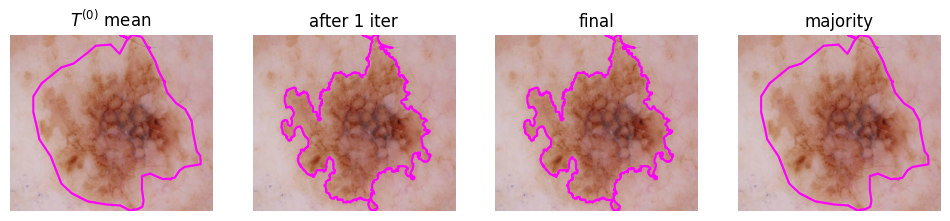

In [22]:
fig, axs = plt.subplots(1, 4, figsize=(12, 3))
panels = [
    (T0, '$T^{(0)}$ mean'),
    (T_hist[1], 'after 1 iter'),
    (T_hist[-1], 'final'),
    (majority.astype(float), 'majority'),
]
for ax, (m, title) in zip(axs, panels):
    ax.imshow(img)
    ax.contour(m >= 0.5, levels=[0.5], colors=['magenta'], linewidths=1.5)
    ax.set_title(title)
    ax.axis('off')
plt.show()

The mask changes on iteration 1 and then stays; extra iterations only update the skills (A04 sensitivity climbs toward 1, A03 specificity drops).

STAPLE follows the A04 pair because those two masks agree, but that's just because they are near-duplicates. Remember to clean your dataset!